In [2]:
import MDAnalysis as mda
import pandas as pd
from MDAnalysis.analysis import dihedrals
import matplotlib.pyplot as plt
import numpy as np
from MDAnalysis.exceptions import SelectionError

/home/hdwang/.conda/envs/mdanalysis/lib/python3.14/site-packages/MDAnalysis/topology/PDBParser.py:309: UserWarning: PDB file is missing resid information.  Defaulted to '1'
  warnings.warn("PDB file is missing resid information.  "
/home/hdwang/.conda/envs/mdanalysis/lib/python3.14/site-packages/MDAnalysis/coordinates/DCD.py:171: DeprecationWarning: DCDReader currently makes independent timesteps by copying self.ts while other readers update self.ts inplace. This behavior will be changed in 3.0 to be the same as other readers. Read more at https://github.com/MDAnalysis/mdanalysis/issues/3889 to learn if this change in behavior might affect you.
  warnings.warn("DCDReader currently makes independent timesteps"


Found 381 phi and 381 psi torsions. Skipped: phi=1, psi=1
Chosen monomer label: 1


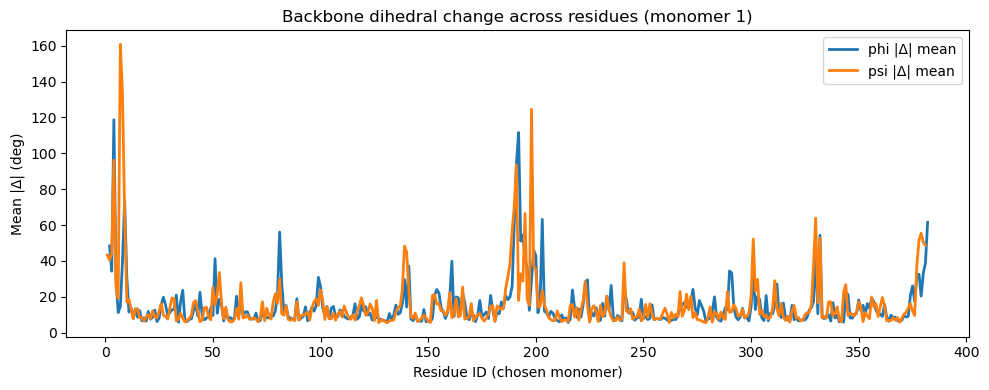

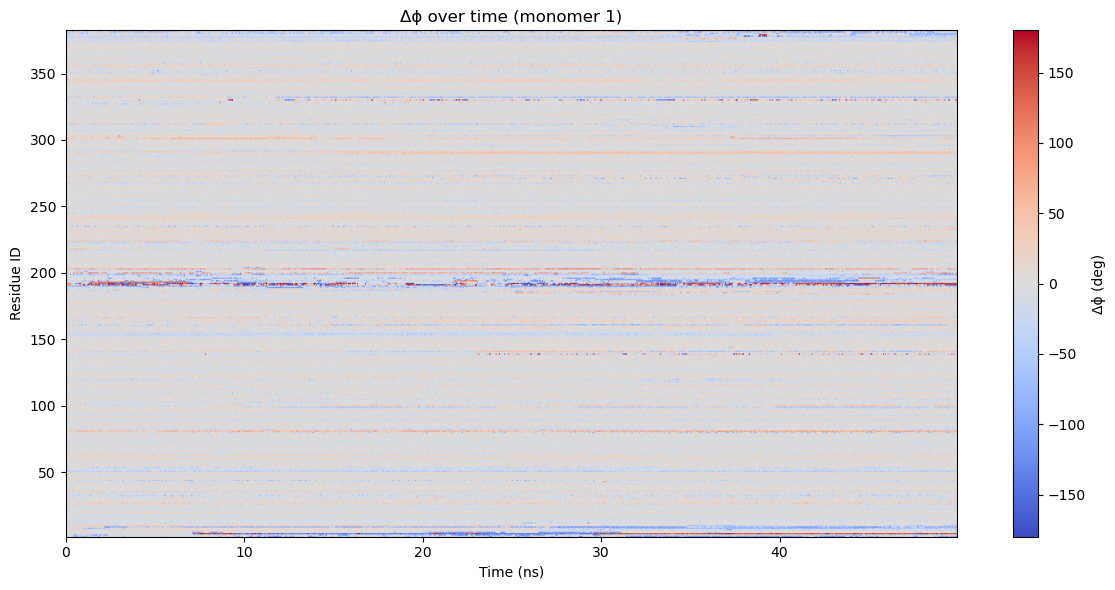

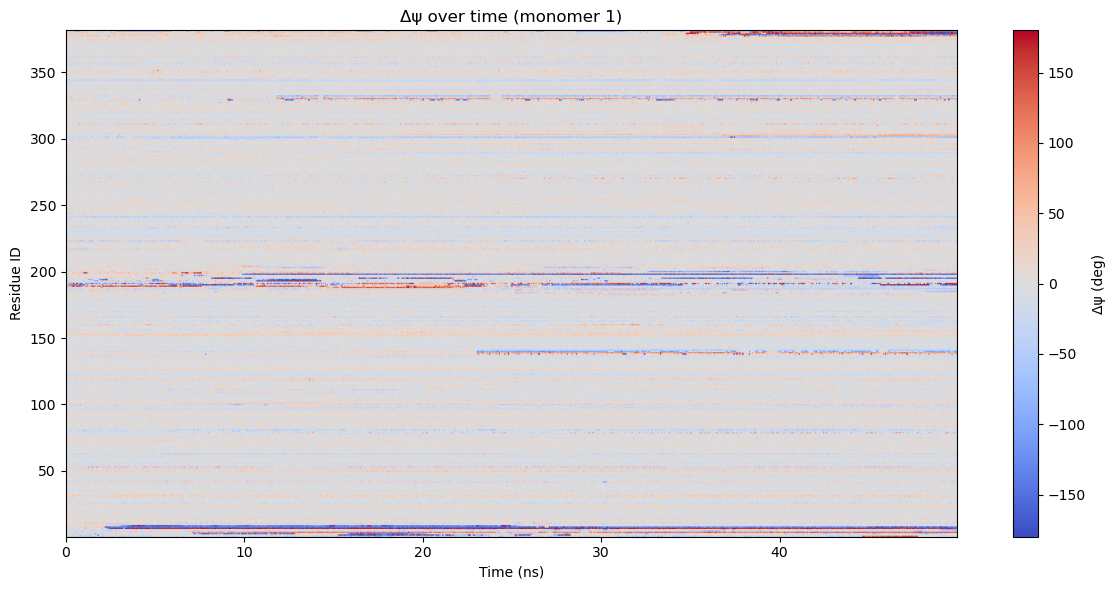

In [ ]:
# pip install MDAnalysis numpy pandas matplotlib
import MDAnalysis as mda
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from MDAnalysis.analysis.dihedrals import Dihedral
from MDAnalysis.exceptions import SelectionError, NoDataError

pdb_traj = '/home/hdwang/sensor_hd/202601/MD4TF/MD4ATF_results_repeat1/AcrR_TEScopy1/06_Production_MD/trajectory.pdb'
pdb_dcd  = '/home/hdwang/sensor_hd/202601/MD4TF/MD4ATF_results_repeat1/AcrR_TEScopy1/06_Production_MD/trajectory.dcd'

u = mda.Universe(pdb_traj, pdb_dcd)
protein = u.select_atoms("protein")
residues = protein.residues
n_frames = len(u.trajectory)

def chain_label(res):
    # Prefer chainID; fallback to segid; finally to segment index
    try:
        label = res.chainID
    except NoDataError:
        label = None
    if not label or (isinstance(label, str) and label.strip() == ""):
        try:
            label = res.segid
        except NoDataError:
            label = None
    if not label or (isinstance(label, str) and label.strip() == ""):
        label = f"seg{res.segment.index}"
    return label

# Build phi/psi AtomGroups and metadata (robust to None/undefined)
phi_ag, psi_ag = [], []
phi_meta, psi_meta = [], []
n_phi_skipped, n_psi_skipped = 0, 0

for res in residues:
    # Phi
    try:
        ag = res.phi_selection()
    except SelectionError:
        ag = None
    if ag is not None and len(ag) == 4:
        phi_ag.append(ag)
        phi_meta.append((chain_label(res), res.resid, res.resname))
    else:
        n_phi_skipped += 1

    # Psi
    try:
        ag = res.psi_selection()
    except SelectionError:
        ag = None
    if ag is not None and len(ag) == 4:
        psi_ag.append(ag)
        psi_meta.append((chain_label(res), res.resid, res.resname))
    else:
        n_psi_skipped += 1

print(f"Found {len(phi_ag)} phi and {len(psi_ag)} psi torsions. Skipped: phi={n_phi_skipped}, psi={n_psi_skipped}")
if len(phi_ag) == 0 or len(psi_ag) == 0:
    raise RuntimeError("No phi/psi dihedrals found. Check protein selection, chain breaks, or missing atoms.")

# Compute angles (degrees in [-180, 180])
phi_deg = Dihedral(phi_ag).run().results.angles  # shape (n_frames, n_phi)
psi_deg = Dihedral(psi_ag).run().results.angles  # shape (n_frames, n_psi)

# Force time axis to 50 ns total over n_frames frames (homodimer case: 1000 frames -> 0.05 ns/frame)
total_ns = 50.0
time_ns = np.arange(n_frames) * (total_ns / n_frames)

# Circular difference helper (degrees)
def angdiff_deg(a, ref):
    return (a - ref + 180.0) % 360.0 - 180.0

phi_ref = phi_deg[0, :]
psi_ref = psi_deg[0, :]

dphi = angdiff_deg(phi_deg, phi_ref)  # (frames, n_phi)
dpsi = angdiff_deg(psi_deg, psi_ref)  # (frames, n_psi)

# Per-residue summary stats
phi_mean_abs = np.mean(np.abs(dphi), axis=0)
psi_mean_abs = np.mean(np.abs(dpsi), axis=0)
phi_rms = np.sqrt(np.mean(dphi**2, axis=0))
psi_rms = np.sqrt(np.mean(dpsi**2, axis=0))

# Indices and summaries
phi_index = pd.MultiIndex.from_tuples(phi_meta, names=["chain_or_seg", "resid", "resname"])
psi_index = pd.MultiIndex.from_tuples(psi_meta, names=["chain_or_seg", "resid", "resname"])

phi_summary = pd.DataFrame({"mean_abs_change_deg": phi_mean_abs,
                            "rms_change_deg": phi_rms},
                           index=phi_index)
psi_summary = pd.DataFrame({"mean_abs_change_deg": psi_mean_abs,
                            "rms_change_deg": psi_rms},
                           index=psi_index)

phi_summary.to_csv("phi_change_summary.csv")
psi_summary.to_csv("psi_change_summary.csv")

# Time series
phi_ts = pd.DataFrame(dphi, columns=phi_index)
psi_ts = pd.DataFrame(dpsi, columns=psi_index)
phi_ts.index = pd.Index(time_ns, name="time_ns")
psi_ts.index = pd.Index(time_ns, name="time_ns")

phi_ts.to_csv("phi_change_timeseries.csv")
psi_ts.to_csv("psi_change_timeseries.csv")

# --------------------------
# Choose one monomer (half)
# --------------------------
chains_phi = list(pd.unique(phi_index.get_level_values("chain_or_seg")))
chains_psi = list(pd.unique(psi_index.get_level_values("chain_or_seg")))
# Prefer 'A' if present, else first
chosen_chain = "A" if "A" in chains_phi else chains_phi[0]
print(f"Chosen monomer label: {chosen_chain}")



# Extract summaries for the chosen chain and sort by resid
phi_sum_A = phi_summary.xs(chosen_chain, level="chain_or_seg").sort_index(level="resid")
psi_sum_A = psi_summary.xs(chosen_chain, level="chain_or_seg").sort_index(level="resid")

# 1) Plot dihedral change across residue ID (mean |Δ| per residue)
plt.figure(figsize=(10, 4))
plt.plot(phi_sum_A.index.get_level_values("resid"), phi_sum_A["mean_abs_change_deg"], label="phi |Δ| mean", lw=2)
plt.plot(psi_sum_A.index.get_level_values("resid"), psi_sum_A["mean_abs_change_deg"], label="psi |Δ| mean", lw=2)
plt.xlabel("Residue ID (chosen monomer)")
plt.ylabel("Mean |Δ| (deg)")
plt.title(f"Backbone dihedral change across residues (monomer {chosen_chain})")
plt.legend()
plt.tight_layout()
plt.show()

# 2) Plot time vs residue heatmaps for the chosen monomer
# Filter columns to chosen chain and sort by resid
phi_ts_A = phi_ts.loc[:, phi_ts.columns.get_level_values("chain_or_seg") == chosen_chain]
psi_ts_A = psi_ts.loc[:, psi_ts.columns.get_level_values("chain_or_seg") == chosen_chain]

if phi_ts_A.shape[1] > 0:
    order_phi = np.argsort(phi_ts_A.columns.get_level_values("resid"))
    phi_ts_A = phi_ts_A.iloc[:, order_phi]
    phi_resids = phi_ts_A.columns.get_level_values("resid").to_numpy()
    phi_mat = phi_ts_A.to_numpy().T  # (residues, time)

    plt.figure(figsize=(12, 6))
    plt.imshow(phi_mat, aspect="auto", cmap="coolwarm", vmin=-180, vmax=180,
               extent=[time_ns.min(), time_ns.max(), phi_resids[0]-0.5, phi_resids[-1]+0.5],
               origin="lower")
    plt.colorbar(label="Δϕ (deg)")
    plt.xlabel("Time (ns)")
    plt.ylabel("Residue ID")
    plt.title(f"Δϕ over time (monomer {chosen_chain})")
    plt.tight_layout()
    plt.show()

if psi_ts_A.shape[1] > 0:
    order_psi = np.argsort(psi_ts_A.columns.get_level_values("resid"))
    psi_ts_A = psi_ts_A.iloc[:, order_psi]
    psi_resids = psi_ts_A.columns.get_level_values("resid").to_numpy()
    psi_mat = psi_ts_A.to_numpy().T

    plt.figure(figsize=(12, 6))
    plt.imshow(psi_mat, aspect="auto", cmap="coolwarm", vmin=-180, vmax=180,
               extent=[time_ns.min(), time_ns.max(), psi_resids[0]-0.5, psi_resids[-1]+0.5],
               origin="lower")
    plt.colorbar(label="Δψ (deg)")
    plt.xlabel("Time (ns)")
    plt.ylabel("Residue ID")
    plt.title(f"Δψ over time (monomer {chosen_chain})")
    plt.tight_layout()
    plt.show()

# Optional: also save chain-specific CSVs
phi_sum_A.to_csv(f"phi_change_summary_chain_{chosen_chain}.csv")
psi_sum_A.to_csv(f"psi_change_summary_chain_{chosen_chain}.csv")
phi_ts_A.to_csv(f"phi_change_timeseries_chain_{chosen_chain}.csv")
psi_ts_A.to_csv(f"psi_change_timeseries_chain_{chosen_chain}.csv")
